In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import pandas as pd
import os

In [27]:
# ========================
# 1️⃣ Paths & Parameters
# ========================
data_dir = r"C:\Users\SUBHRAJYOTI BASU\Documents\PCOS Detection\PCOS"  # main folder
csv_path = os.path.join(data_dir, "class_label.csv")
img_dir = os.path.join(data_dir, "images")

batch_size = 32
img_size = 224
num_epochs = 50
lr = 1e-4
val_split = 0.2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
# ========================
# 2️⃣ Read CSV and Map Labels
# ========================
df = pd.read_csv(csv_path)

# Normalize column names if they contain spaces
df.columns = df.columns.str.strip()
df['Class label (whether polycsytic ovary is visible or not visible)'] = df['Class label (whether polycsytic ovary is visible or not visible)'].str.strip()

# Map labels to integers
label_map = {"Visible": 1, "Not-visible": 0}
df['label'] = df['Class label (whether polycsytic ovary is visible or not visible)'].map(label_map)

In [20]:
df

,imagePath,Class label (whether the ultrasound images appears normal or has some abnormality),Class label (whether polycsytic ovary is visible or not visible),label
0,image10000.jpg,Appears normal,Not-visible,0
1,image10001.jpg,Appears abnormal,Visible,1
2,image10002.jpg,Appears normal,Not-visible,0
3,image10003.jpg,Appears abnormal,Not-visible,0
4,image10004.jpg,Appears abnormal,Visible,1
...,...,...,...,...
1463,image11463.jpg,Appears abnormal,Not-visible,0
1464,image11464.jpg,Appears abnormal,Visible,1
1465,image11465.jpg,Appears abnormal,Not-visible,0
1466,image11466.jpg,Appears normal,Not-visible,0


In [21]:
# ========================
# 3️⃣ Custom Dataset Class
# ========================
class PCOSDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['imagePath']
        label = int(self.df.iloc[idx]['label'])
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [22]:
# ========================
# 4️⃣ Data Augmentation
# ========================
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [23]:
# ========================
# 5️⃣ Create Dataset and Split
# ========================
full_dataset = PCOSDataset(df, img_dir, transform=train_transform)
val_size = int(len(full_dataset) * val_split)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Assign different transform for validation
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [24]:
# ========================
# 6️⃣ Load Pretrained ResNet
# ========================
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in model.parameters():
    param.requires_grad = False  # freeze feature extractor

# Replace final layer for binary classification
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 2)
)
model = model.to(device)

In [28]:
# ========================
# 7️⃣ Loss & Optimizer
# ========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=lr)

# ========================
# 8️⃣ Training Loop
# ========================
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_loss = running_loss / len(train_dataset)

    # ---- Validation ----
    model.eval()
    val_correct, val_total, val_loss = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss = val_loss / len(val_dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet50_pcos.pth")

print("✅ Training complete. Best Val Acc:", best_val_acc)

Epoch [1/50] Train Loss: 0.1847  Train Acc: 0.9243 Val Loss: 0.2961  Val Acc: 0.8669
Epoch [2/50] Train Loss: 0.1814  Train Acc: 0.9336 Val Loss: 0.3002  Val Acc: 0.8737
Epoch [3/50] Train Loss: 0.1803  Train Acc: 0.9277 Val Loss: 0.2932  Val Acc: 0.8737
Epoch [4/50] Train Loss: 0.1786  Train Acc: 0.9328 Val Loss: 0.2910  Val Acc: 0.8771
Epoch [5/50] Train Loss: 0.1672  Train Acc: 0.9336 Val Loss: 0.2968  Val Acc: 0.8737
Epoch [6/50] Train Loss: 0.1713  Train Acc: 0.9387 Val Loss: 0.2990  Val Acc: 0.8737
Epoch [7/50] Train Loss: 0.1614  Train Acc: 0.9345 Val Loss: 0.2979  Val Acc: 0.8737
Epoch [8/50] Train Loss: 0.1664  Train Acc: 0.9328 Val Loss: 0.2973  Val Acc: 0.8805
Epoch [9/50] Train Loss: 0.1483  Train Acc: 0.9447 Val Loss: 0.2951  Val Acc: 0.8805
Epoch [10/50] Train Loss: 0.1643  Train Acc: 0.9413 Val Loss: 0.3149  Val Acc: 0.8703
Epoch [11/50] Train Loss: 0.1470  Train Acc: 0.9464 Val Loss: 0.3134  Val Acc: 0.8703
Epoch [12/50] Train Loss: 0.1528  Train Acc: 0.9404 Val Loss: 0


Classification Report:

              precision    recall  f1-score   support

 Not Visible       0.95      0.85      0.90       195
     Visible       0.76      0.92      0.83        98

    accuracy                           0.87       293
   macro avg       0.86      0.88      0.86       293
weighted avg       0.89      0.87      0.88       293



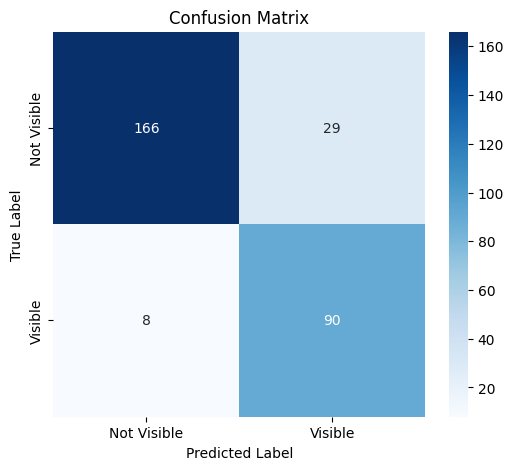

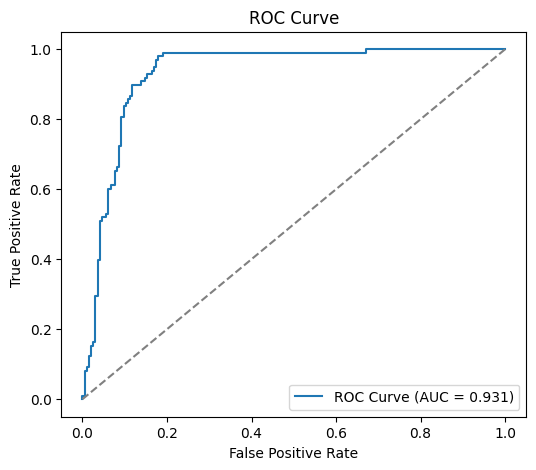


✅ AUC Score: 0.931


In [29]:
import torch
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set model to evaluation mode
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of class 1
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# ================================
# 🔹 1. Classification Report
# ================================
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Not Visible", "Visible"]))

# ================================
# 🔹 2. Confusion Matrix
# ================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Visible", "Visible"], yticklabels=["Not Visible", "Visible"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ================================
# 🔹 3. ROC Curve and AUC
# ================================
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"\n✅ AUC Score: {roc_auc:.3f}")